STEP 1 (EDA)

1. LOAD DATA

In [37]:
import pandas as pd

# load data
df = pd.read_csv("../data/data.csv", encoding='latin1')

# lihat data
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


2. DATA OVERVIEW

In [2]:
print("Shape:", df.shape)
print("\nInfo:")
df.info()

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDescribe:")
df.describe()

Shape: (541909, 8)

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB

Missing Values:
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

Describe:


,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


3. DATA CLEANING

In [3]:
# hapus transaksi tanpa customer
df = df.dropna(subset=['CustomerID'])

# hapus quantity negatif (return)
df = df[df['Quantity'] > 0]

# hapus harga 0
df = df[df['UnitPrice'] > 0]

# buat revenue
df['Revenue'] = df['Quantity'] * df['UnitPrice']

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom,20.34


4. TOP PRODUCTS

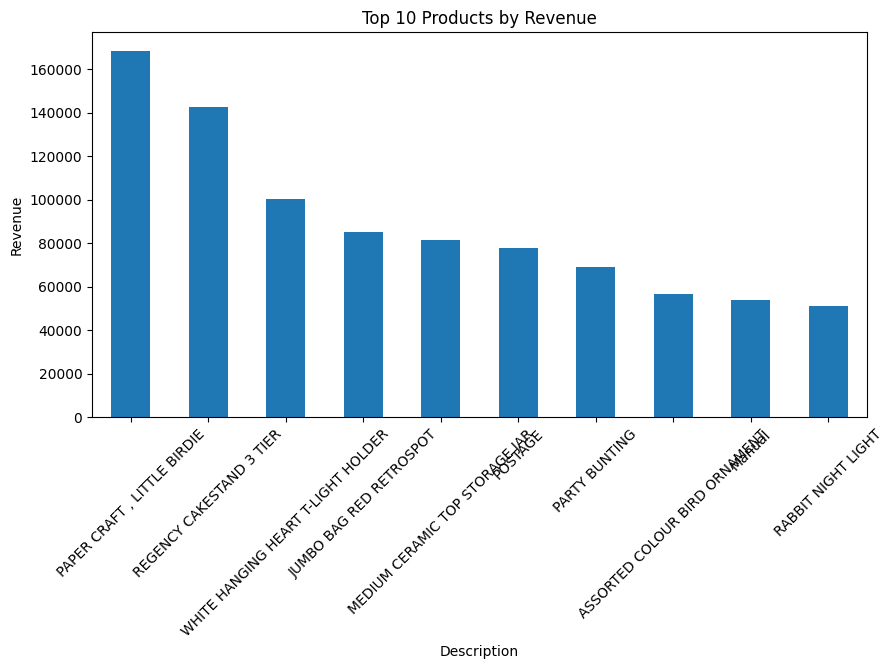

In [4]:
import matplotlib.pyplot as plt

top_products = df.groupby('Description')['Revenue'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
top_products.plot(kind='bar')
plt.title("Top 10 Products by Revenue")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.show()

5. REVENUE BY COUNTRY

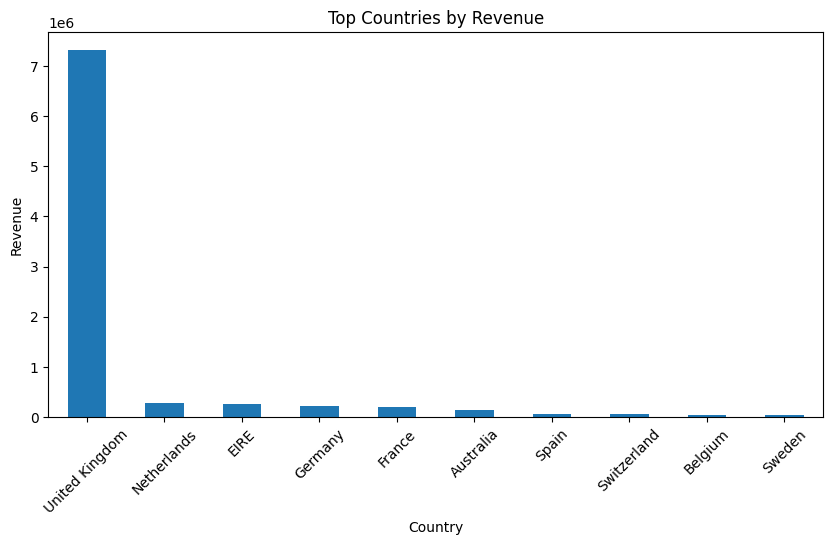

In [5]:
country_revenue = df.groupby('Country')['Revenue'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
country_revenue.plot(kind='bar')
plt.title("Top Countries by Revenue")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.show()

6. SALES TREND

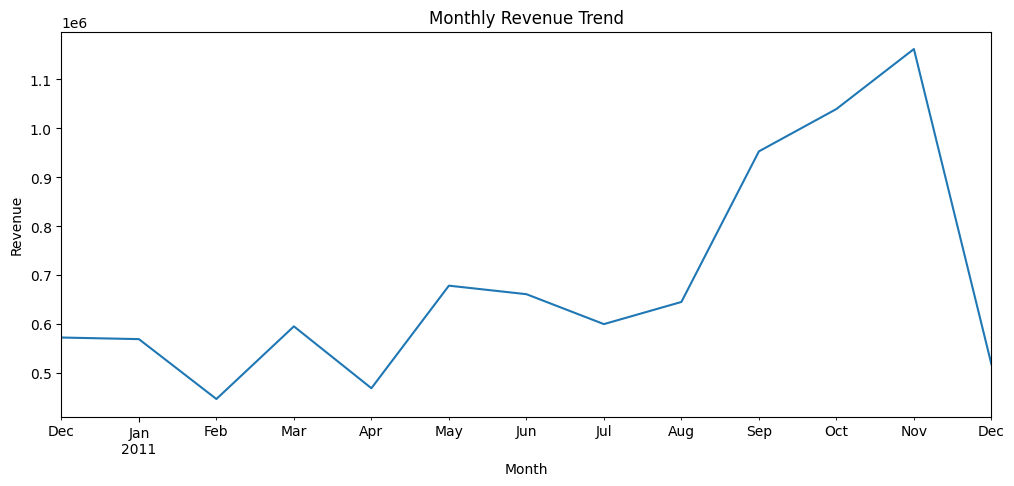

In [6]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

df['Month'] = df['InvoiceDate'].dt.to_period('M')

monthly_revenue = df.groupby('Month')['Revenue'].sum()

plt.figure(figsize=(12,5))
monthly_revenue.plot()
plt.title("Monthly Revenue Trend")
plt.ylabel("Revenue")
plt.show()

7. TOP CUSTOMERS

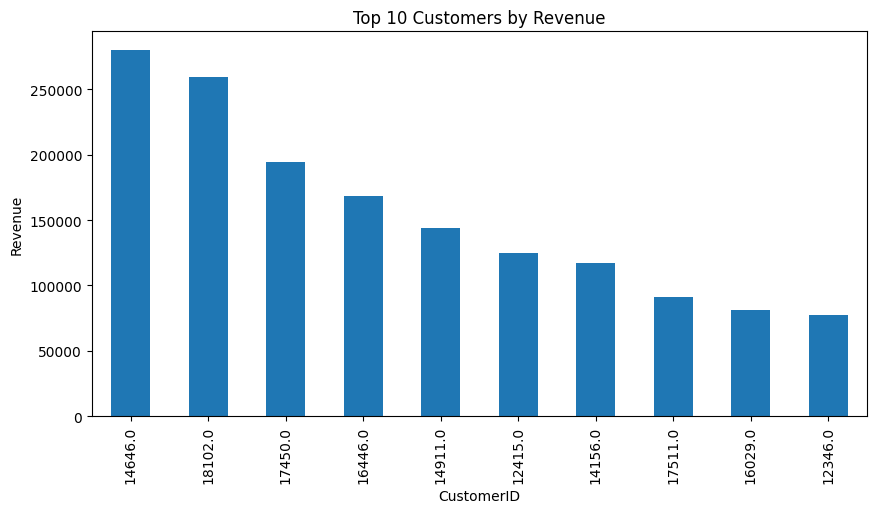

In [7]:
top_customers = df.groupby('CustomerID')['Revenue'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
top_customers.plot(kind='bar')
plt.title("Top 10 Customers by Revenue")
plt.ylabel("Revenue")
plt.show()

STEP 2 — RFM Analysis

1. KONSEP (BIAR NGGAK ASAL CODING)

RFM =

Recency (R) → seberapa lama sejak terakhir transaksi
Frequency (F) → seberapa sering transaksi
Monetary (M) → total uang yang dibelanjakan

2. PREPARE DATA

In [8]:
import pandas as pd

# pastikan datetime
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# reference date (tanggal terakhir + 1 hari)
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

snapshot_date

Timestamp('2011-12-10 12:50:00')

3. HITUNG RFM

In [9]:
rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,
    'InvoiceNo': 'count',
    'Revenue': 'sum'
})

rfm.columns = ['Recency', 'Frequency', 'Monetary']

rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,326,1,77183.60
12347.0,2,182,4310.00
12348.0,75,31,1797.24
12349.0,19,73,1757.55
12350.0,310,17,334.40


4. DISTRIBUSI RFM

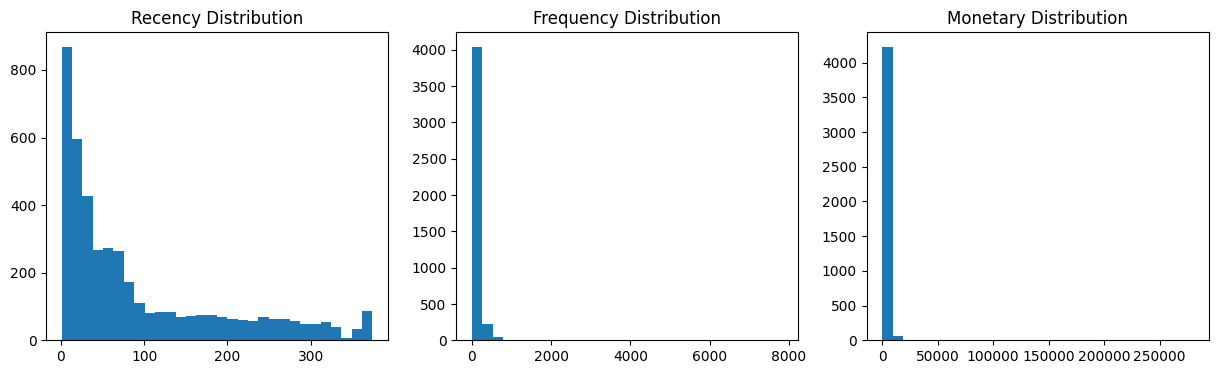

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,4))

plt.subplot(1,3,1)
plt.hist(rfm['Recency'], bins=30)
plt.title("Recency Distribution")

plt.subplot(1,3,2)
plt.hist(rfm['Frequency'], bins=30)
plt.title("Frequency Distribution")

plt.subplot(1,3,3)
plt.hist(rfm['Monetary'], bins=30)
plt.title("Monetary Distribution")

plt.show()

5. RFM SCORING (QUANTILE)

In [11]:
rfm['R_score'] = pd.qcut(rfm['Recency'], 4, labels=[4,3,2,1])
rfm['F_score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 4, labels=[1,2,3,4])
rfm['M_score'] = pd.qcut(rfm['Monetary'], 4, labels=[1,2,3,4])

rfm.head()

,Recency,Frequency,Monetary,R_score,F_score,M_score
CustomerID,,,,,,
12346.0,326,1,77183.60,1,1,4
12347.0,2,182,4310.00,4,4,4
12348.0,75,31,1797.24,2,2,4
12349.0,19,73,1757.55,3,3,4
12350.0,310,17,334.40,1,1,2


6. BUAT RFM SCORE

In [12]:
rfm['RFM_score'] = rfm['R_score'].astype(str) + rfm['F_score'].astype(str) + rfm['M_score'].astype(str)

rfm.head()

,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_score
CustomerID,,,,,,,
12346.0,326,1,77183.60,1,1,4,114
12347.0,2,182,4310.00,4,4,4,444
12348.0,75,31,1797.24,2,2,4,224
12349.0,19,73,1757.55,3,3,4,334
12350.0,310,17,334.40,1,1,2,112


7. SEGMENTASI CUSTOMER

In [13]:
def segment_customer(row):
    if row['R_score'] == 4 and row['F_score'] == 4:
        return 'Champions'
    elif row['F_score'] >= 3:
        return 'Loyal Customers'
    elif row['R_score'] == 4:
        return 'New Customers'
    elif row['R_score'] <= 2:
        return 'At Risk'
    else:
        return 'Others'

rfm['Segment'] = rfm.apply(segment_customer, axis=1)

rfm.head()

,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_score,Segment
CustomerID,,,,,,,,
12346.0,326,1,77183.60,1,1,4,114,At Risk
12347.0,2,182,4310.00,4,4,4,444,Champions
12348.0,75,31,1797.24,2,2,4,224,At Risk
12349.0,19,73,1757.55,3,3,4,334,Loyal Customers
12350.0,310,17,334.40,1,1,2,112,At Risk


8. VISUAL SEGMENTASI

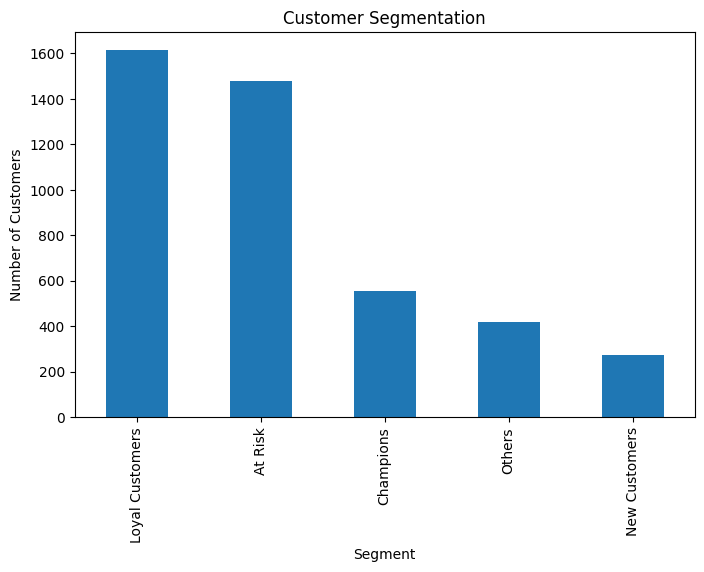

In [14]:
segment_counts = rfm['Segment'].value_counts()

plt.figure(figsize=(8,5))
segment_counts.plot(kind='bar')
plt.title("Customer Segmentation")
plt.ylabel("Number of Customers")
plt.show()

STEP 3 — CUSTOMER SEGMENTATION

1. STRATEGI (KENAPA KMEANS)
Data: RFM (Recency, Frequency, Monetary)
Tujuan: mengelompokkan customer berdasarkan perilaku
Algoritma: KMeans (unsupervised, interpretable, cepat)

2. PREPARE DATA

In [15]:
import pandas as pd

# gunakan rfm dari step sebelumnya
rfm.head()

,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_score,Segment
CustomerID,,,,,,,,
12346.0,326,1,77183.60,1,1,4,114,At Risk
12347.0,2,182,4310.00,4,4,4,444,Champions
12348.0,75,31,1797.24,2,2,4,224,At Risk
12349.0,19,73,1757.55,3,3,4,334,Loyal Customers
12350.0,310,17,334.40,1,1,2,112,At Risk


In [16]:
X = rfm[['Recency', 'Frequency', 'Monetary']]

3. SCALING

In [17]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

4. ELBOW METHOD

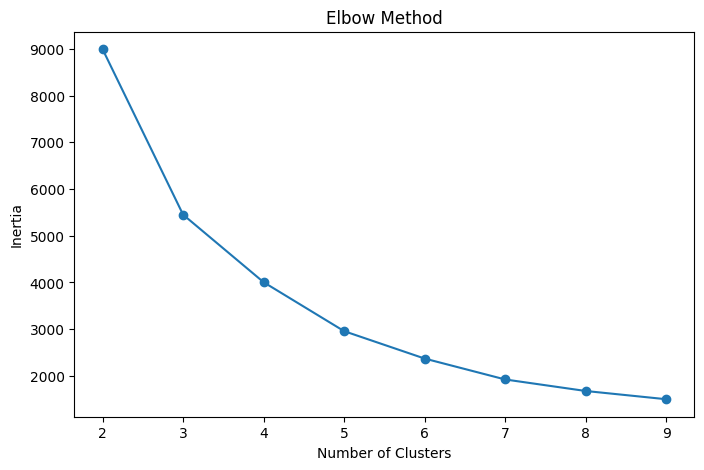

In [18]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []

K_range = range(2, 10)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(K_range, inertia, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.show()

In [19]:
k = 4

5. TRAIN MODEL

In [20]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
rfm['Cluster'] = kmeans.fit_predict(X_scaled)

rfm.head()

,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_score,Segment,Cluster
CustomerID,,,,,,,,,
12346.0,326,1,77183.60,1,1,4,114,At Risk,2
12347.0,2,182,4310.00,4,4,4,444,Champions,0
12348.0,75,31,1797.24,2,2,4,224,At Risk,0
12349.0,19,73,1757.55,3,3,4,334,Loyal Customers,0
12350.0,310,17,334.40,1,1,2,112,At Risk,2


6. VISUAL CLUSTER

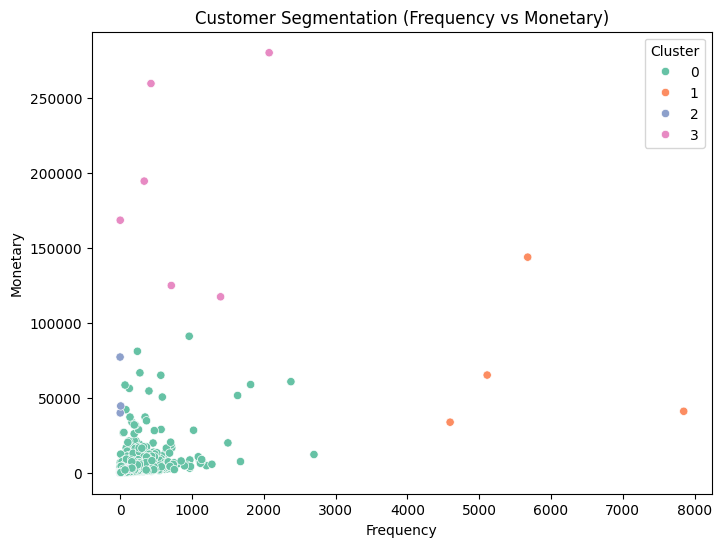

In [21]:
import seaborn as sns

plt.figure(figsize=(8,6))
sns.scatterplot(
    x=rfm['Frequency'],
    y=rfm['Monetary'],
    hue=rfm['Cluster'],
    palette='Set2'
)

plt.title("Customer Segmentation (Frequency vs Monetary)")
plt.show()

7. ANALISIS CLUSTER

In [24]:
cluster_summary = rfm.groupby('Cluster')[['Recency', 'Frequency', 'Monetary']].mean()

cluster_summary

,Recency,Frequency,Monetary
Cluster,,,
0,41.341133,104.582512,2091.817116
1,2.000000,5807.000000,70925.287500
2,247.308333,27.787963,637.318510
3,7.666667,826.833333,190863.461667


8. NAMING CLUSTER

In [26]:
def label_cluster(row):
    if row['Monetary'] > rfm['Monetary'].median() and row['Frequency'] > rfm['Frequency'].median():
        return 'High Value'
    elif row['Recency'] > rfm['Recency'].median():
        return 'At Risk'
    elif row['Frequency'] < rfm['Frequency'].median():
        return 'Low Engagement'
    else:
        return 'Regular'

rfm['Cluster_Label'] = rfm.apply(label_cluster, axis=1)

rfm.head()

,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_score,Segment,Cluster,Cluster_Label
CustomerID,,,,,,,,,,
12346.0,326,1,77183.60,1,1,4,114,At Risk,2,At Risk
12347.0,2,182,4310.00,4,4,4,444,Champions,0,High Value
12348.0,75,31,1797.24,2,2,4,224,At Risk,0,At Risk
12349.0,19,73,1757.55,3,3,4,334,Loyal Customers,0,High Value
12350.0,310,17,334.40,1,1,2,112,At Risk,2,At Risk


9. DISTRIBUSI SEGMENT

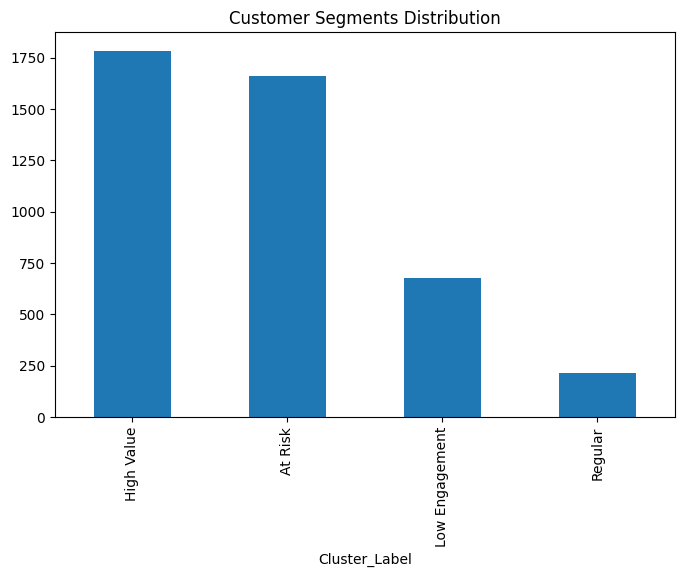

In [27]:
rfm['Cluster_Label'].value_counts().plot(kind='bar', figsize=(8,5))
plt.title("Customer Segments Distribution")
plt.show()

STEP 4 — RECOMMENDATION SYSTEM

1. KONSEP

“Customers who bought X also bought Y”

2. PREPARE DATA

In [28]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue,Month
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,2010-12
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010-12
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,2010-12
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010-12
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010-12


3. BUAT BASKET MATRIX

In [29]:
basket = df.groupby(['InvoiceNo', 'Description'])['Quantity'].sum().unstack().fillna(0)

basket.head()

Description,4 PURPLE FLOCK DINNER CANDLES,50'S CHRISTMAS GIFT BAG LARGE,DOLLY GIRL BEAKER,I LOVE LONDON MINI BACKPACK,I LOVE LONDON MINI RUCKSACK,NINE DRAWER OFFICE TIDY,OVAL WALL MIRROR DIAMANTE,RED SPOT GIFT BAG LARGE,SET 2 TEA TOWELS I LOVE LONDON,SPACEBOY BABY GIFT SET,...,ZINC STAR T-LIGHT HOLDER,ZINC SWEETHEART SOAP DISH,ZINC SWEETHEART WIRE LETTER RACK,ZINC T-LIGHT HOLDER STAR LARGE,ZINC T-LIGHT HOLDER STARS LARGE,ZINC T-LIGHT HOLDER STARS SMALL,ZINC TOP 2 DOOR WOODEN SHELF,ZINC WILLIE WINKIE CANDLE STICK,ZINC WIRE KITCHEN ORGANISER,ZINC WIRE SWEETHEART LETTER TRAY
InvoiceNo,,,,,,,,,,,,,,,,,,,,,
536365,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
536366,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
536367,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
536368,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
536369,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


4. BINARIZATION

In [31]:
co_matrix = basket.T.dot(basket)
co_matrix.head()

Description,4 PURPLE FLOCK DINNER CANDLES,50'S CHRISTMAS GIFT BAG LARGE,DOLLY GIRL BEAKER,I LOVE LONDON MINI BACKPACK,I LOVE LONDON MINI RUCKSACK,NINE DRAWER OFFICE TIDY,OVAL WALL MIRROR DIAMANTE,RED SPOT GIFT BAG LARGE,SET 2 TEA TOWELS I LOVE LONDON,SPACEBOY BABY GIFT SET,...,ZINC STAR T-LIGHT HOLDER,ZINC SWEETHEART SOAP DISH,ZINC SWEETHEART WIRE LETTER RACK,ZINC T-LIGHT HOLDER STAR LARGE,ZINC T-LIGHT HOLDER STARS LARGE,ZINC T-LIGHT HOLDER STARS SMALL,ZINC TOP 2 DOOR WOODEN SHELF,ZINC WILLIE WINKIE CANDLE STICK,ZINC WIRE KITCHEN ORGANISER,ZINC WIRE SWEETHEART LETTER TRAY
Description,,,,,,,,,,,,,,,,,,,,,
4 PURPLE FLOCK DINNER CANDLES,1098.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,12.0,0.0,0.0,0.0,0.0,0.0,0.0
50'S CHRISTMAS GIFT BAG LARGE,0.0,186633.0,144.0,40.0,0.0,0.0,0.0,167848.0,0.0,156.0,...,0.0,0.0,0.0,288.0,0.0,1056.0,0.0,0.0,0.0,0.0
DOLLY GIRL BEAKER,0.0,144.0,453094.0,50.0,0.0,48.0,1.0,41.0,0.0,231.0,...,0.0,0.0,48.0,146.0,0.0,162.0,0.0,38400.0,0.0,0.0
I LOVE LONDON MINI BACKPACK,0.0,40.0,50.0,7630.0,0.0,16.0,0.0,40.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4800.0,0.0,0.0
I LOVE LONDON MINI RUCKSACK,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


5. CO-OCCURRENCE MATRIX

In [32]:
def recommend_products(product_name, top_n=5):
    if product_name not in co_matrix.index:
        return "Product not found"
    
    similar = co_matrix[product_name].sort_values(ascending=False)
    
    # remove dirinya sendiri
    similar = similar.drop(product_name)
    
    return similar.head(top_n)

6. FUNCTION RECOMMENDATION

In [33]:
def recommend_products(product_name, top_n=5):
    if product_name not in co_matrix.index:
        return "Product not found"
    
    similar = co_matrix[product_name].sort_values(ascending=False)
    
    # remove dirinya sendiri
    similar = similar.drop(product_name)
    
    return similar.head(top_n)

7. COBA REKOMENDASI

In [34]:
recommend_products("WHITE HANGING HEART T-LIGHT HOLDER")

Description
FAIRY CAKE FLANNEL ASSORTED COLOUR    12027819.0
GIN + TONIC DIET METAL SIGN            7889458.0
HEART OF WICKER SMALL                  2655053.0
TEA TIME TEA TOWELS                    2509000.0
HEART OF WICKER LARGE                  1946483.0
Name: WHITE HANGING HEART T-LIGHT HOLDER, dtype: float64

8. VISUAL

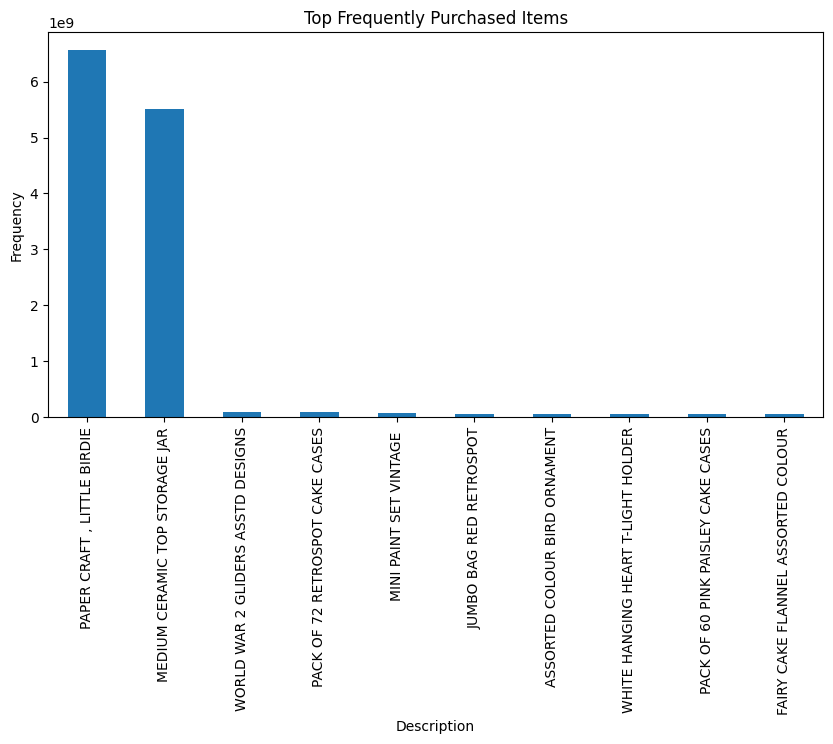

In [35]:
top_items = co_matrix.sum().sort_values(ascending=False).head(10)

import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
top_items.plot(kind='bar')
plt.title("Top Frequently Purchased Items")
plt.ylabel("Frequency")
plt.show()

STEP 5 — STREAMLIT APP